In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = '/content/drive/MyDrive/AnemiaFusionNet'
folders = ['datasets', 'models', 'checkpoints', 'results']

for folder in folders:
    os.makedirs(f'{base_path}/{folder}', exist_ok=True)
    print(f'Created: {folder}')

print("All folders created successfully!")

Created: datasets
Created: models
Created: checkpoints
Created: results
All folders created successfully!


In [ ]:
# Install all required libraries for AnemiaFusionNet
!pip install torch torchvision torchaudio --quiet
!pip install transformers --quiet
!pip install timm --quiet                    # For Vision Transformers
!pip install scikit-learn pandas numpy --quiet
!pip install matplotlib seaborn --quiet
!pip install wandb --quiet                   # For experiment tracking
!pip install Pillow opencv-python --quiet
!pip install tqdm --quiet

print("All libraries installed successfully!")

All libraries installed successfully!


In [ ]:
import torch
import torchvision
import transformers
import timm
import sklearn
import pandas as pd
import numpy as np
import cv2
import matplotlib

print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"Transformers version: {transformers.__version__}")
print("All imports successful!")

PyTorch version: 2.11.0+cu128
GPU Available: True
Transformers version: 5.12.0
All imports successful!


In [ ]:
# Upload your kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hridayakatangale","key":"1c1f58379af94f375ad18d23545178d4"}'}

In [ ]:
# Setup Kaggle
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API ready!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API ready!


In [ ]:
# Download the dataset
!kaggle datasets download -d navoneel/anemia-types-classification --unzip -p /content/drive/MyDrive/AnemiaFusionNet/datasets/

print("Dataset downloaded!")

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Dataset downloaded!


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/AnemiaFusionNet/datasets'

# See all files and folders
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show only first 5 files per folder
        print(f'{subindent}{file}')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
import shutil

# Setup kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle authenticated!")

Kaggle authenticated!


In [ ]:
!kaggle datasets list -s "anemia conjunctiva"

ref                                     title                                         size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------  --------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
harshwardhanfartale/eyes-defy-anemia    EYES-DEFY-ANEMIA                         666269625  2024-04-14 06:12:24.887000           4189         29  0.75             
nahiyan1402/anemiadataset               Eye Images Dataset (Anemia Prediction)        2280  2022-05-30 03:03:44.610000           1454         19  0.7058824        
ramya125g/balanced-conjunctiva-dataset  balanced_conjunctiva_dataset             110930460  2025-08-15 05:59:29.200000              4          0  0.3125           
nadiwidi/eyeconjunctiva                 Eye-Conjunctiva                            1718262  2022-12-13 13:36:35.683000            193          0  0.25             


In [ ]:
!kaggle datasets download -d harshwardhanfartale/eyes-defy-anemia --unzip -p /content/drive/MyDrive/AnemiaFusionNet/datasets/

print("Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/harshwardhanfartale/eyes-defy-anemia
License(s): CC-BY-SA-4.0
100% 635M/635M [00:10<00:00, 65.9MB/s]

Dataset downloaded successfully!


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/AnemiaFusionNet/datasets'

print("Everything inside datasets folder:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files per folder
        print(f'{subindent}{file}')

Everything inside datasets folder:
datasets/
  dataset anemia/
    Dataset anemia.docx
    Italy/
      Italy.xlsx
      10/
        010_forniceal_palpebral.png
        10.jpg
        010_palpebral.png
        010_forniceal.png
      60/
        T_29_20190608_110432.jpg
        T_29_20190608_110432_forniceal_palpebral.png
        T_29_20190608_110432_forniceal.png
        T_29_20190608_110432_palpebral.png
      68/
        T_37_20190610_085835_palpebral.png
        T_37_20190610_085835_forniceal.png
        T_37_20190610_085835.jpg
        T_37_20190610_085835_forniceal_palpebral.png
      46/
        T_15_20190608_075438.jpg
        T_15_20190608_075438_forniceal_palpebral.png
        T_15_20190608_075438_forniceal.png
        T_15_20190608_075438_palpebral.png
      81/
        T_50_20190612_080012_forniceal_palpebral.png
        T_50_20190612_080012_palpebral.png
        T_50_20190612_080012.jpg
        T_50_20190612_080012_forniceal.png
      12/
        012_forniceal_palpebral.pn

Total images found: 862


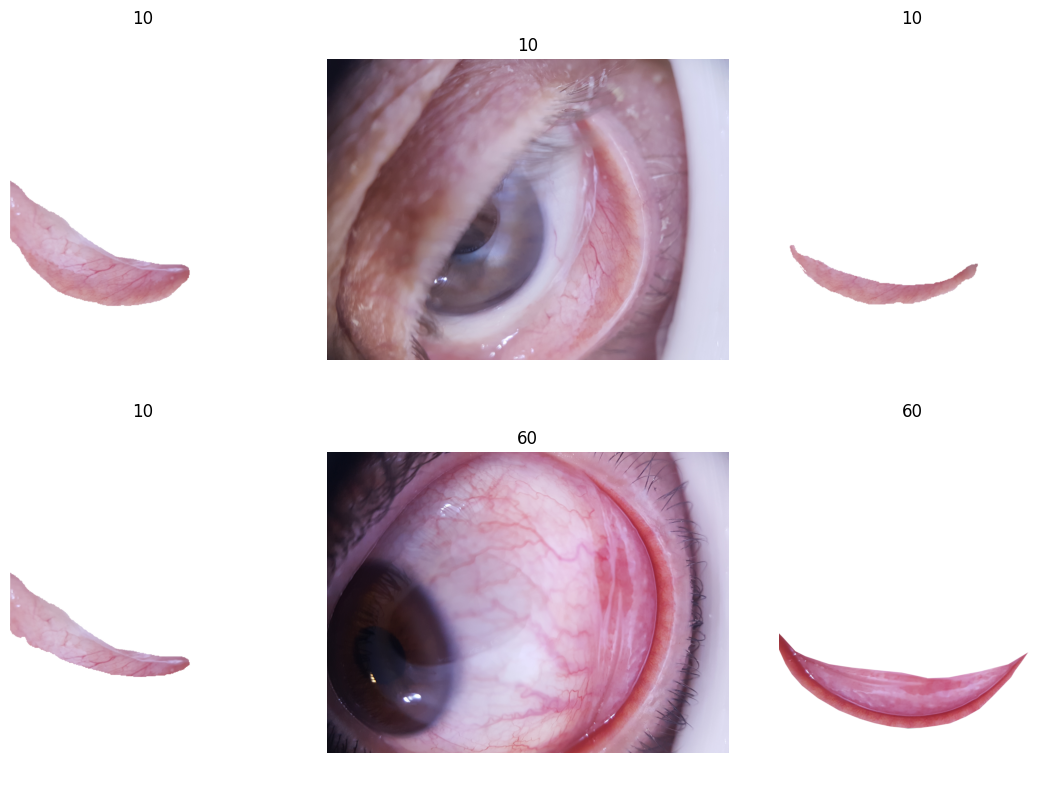

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Find all images
image_extensions = ['.jpg', '.jpeg', '.png']
all_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if any(file.lower().endswith(ext) for ext in image_extensions):
            all_images.append(os.path.join(root, file))

print(f"Total images found: {len(all_images)}")

# Display first 6 images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i < len(all_images):
        img = mpimg.imread(all_images[i])
        ax.imshow(img)
        ax.set_title(all_images[i].split('/')[-2])
        ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/AnemiaFusionNet/datasets'

print("Folder structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')

Folder structure:
datasets/ (0 files)
  dataset anemia/ (1 files)
    Italy/ (1 files)
      10/ (4 files)
      60/ (4 files)
      68/ (4 files)
      46/ (4 files)
      81/ (4 files)
      12/ (4 files)
      3/ (4 files)
      44/ (4 files)
      15/ (4 files)
      32/ (4 files)
      57/ (4 files)
      94/ (4 files)
      84/ (4 files)
      74/ (4 files)
      14/ (4 files)
      70/ (4 files)
      26/ (4 files)
      92/ (4 files)
      45/ (4 files)
      72/ (4 files)
      111/ (4 files)
      121/ (4 files)
      76/ (4 files)
      54/ (2 files)
      21/ (4 files)
      77/ (4 files)
      110/ (4 files)
      123/ (4 files)
      51/ (4 files)
      11/ (4 files)
      48/ (4 files)
      16/ (4 files)
      19/ (4 files)
      5/ (4 files)
      8/ (4 files)
      25/ (4 files)
      101/ (4 files)
      58/ (2 files)
      43/ (4 files)
      33/ (4 files)
      1/ (2 files)
      30/ (4 files)
      73/ (4 files)
      95/ (4 files)
      113/ (4 files)
      120/ 

In [ ]:
import os
import pandas as pd

dataset_path = '/content/drive/MyDrive/AnemiaFusionNet/datasets'

# Check what's inside one patient folder
sample_patient = f'{dataset_path}/dataset anemia/Italy/10'
print("Files inside one patient folder:")
for f in os.listdir(sample_patient):
    print(f)

print("\n")

# Find any CSV or Excel files (clinical data)
print("Looking for clinical data files:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.csv') or file.endswith('.xlsx') or file.endswith('.json') or file.endswith('.txt'):
            print(os.path.join(root, file))

Files inside one patient folder:
010_forniceal_palpebral.png
10.jpg
010_palpebral.png
010_forniceal.png


Looking for clinical data files:
/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/Italy/Italy.xlsx
/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/India/India.xlsx


In [ ]:
import pandas as pd

# Read both excel files
italy_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/Italy/Italy.xlsx')
india_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/India/India.xlsx')

print("=== ITALY DATASET ===")
print(f"Shape: {italy_df.shape}")
print(italy_df.head())
print("\nColumns:", italy_df.columns.tolist())

print("\n=== INDIA DATASET ===")
print(f"Shape: {india_df.shape}")
print(india_df.head())
print("\nColumns:", india_df.columns.tolist())

=== ITALY DATASET ===
Shape: (123, 9)
   Number   Hgb Gender  Age                               Note  Unnamed: 5  \
0       1   9.3      F   82  Forniceal conjunctiva not visible         NaN   
1       2  10.2      F   77       da segmentare la forniceale          NaN   
2       3  10.7      F   52       da segmentare la forniceale          NaN   
3       4  11.7      F   73       da segmentare la forniceale          NaN   
4       5  11.6      F   74       da segmentare la forniceale          NaN   

  Unnamed: 6 Unnamed: 7             Unnamed: 8  
0        NaN        NaN                    NaN  
1        NaN        NaN  Segmentato da Michele  
2        NaN        NaN  Segmentato da Michele  
3        NaN        NaN  Segmentato da Michele  
4        NaN        NaN  Segmentato da Michele  

Columns: ['Number', 'Hgb', 'Gender', 'Age', 'Note', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

=== INDIA DATASET ===
Shape: (95, 5)
   Number   Hgb Gender  Age  Note
0       1  12.2   

In [ ]:
import pandas as pd
import numpy as np

# Read both datasets
italy_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/Italy/Italy.xlsx')
india_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/India/India.xlsx')

# Keep only useful columns
italy_df = italy_df[['Number', 'Hgb', 'Gender', 'Age']].copy()
india_df = india_df[['Number', 'Hgb', 'Gender', 'Age']].copy()

# Add country column
italy_df['Country'] = 'Italy'
india_df['Country'] = 'India'

# Combine both
df = pd.concat([italy_df, india_df], ignore_index=True)

# Convert Hgb to numeric, force errors to NaN
df['Hgb'] = pd.to_numeric(df['Hgb'], errors='coerce')

# Drop rows where Hgb is NaN
df = df.dropna(subset=['Hgb'])

# Clean Gender column
df['Gender'] = df['Gender'].str.strip().str.upper()

print("Unique Gender values:", df['Gender'].unique())
print("Hgb dtype:", df['Hgb'].dtype)
print(f"Total clean patients: {len(df)}")

# Create Anemia Label using WHO standards
def label_anemia(row):
    if row['Gender'] == 'F' and row['Hgb'] < 12:
        return 1  # Anemic
    elif row['Gender'] == 'M' and row['Hgb'] < 13:
        return 1  # Anemic
    else:
        return 0  # Non-Anemic

df['Anemia_Label'] = df.apply(label_anemia, axis=1)

print(f"\nAnemia distribution:")
print(df['Anemia_Label'].value_counts())
print(f"\nSample data:")
print(df.head(10))

Unique Gender values: ['F' 'M']
Hgb dtype: float64
Total clean patients: 202

Anemia distribution:
Anemia_Label
0    112
1     90
Name: count, dtype: int64

Sample data:
   Number   Hgb Gender  Age Country  Anemia_Label
0       1   9.3      F   82   Italy             1
1       2  10.2      F   77   Italy             1
2       3  10.7      F   52   Italy             1
3       4  11.7      F   73   Italy             1
4       5  11.6      F   74   Italy             1
5       6  15.0      F   77   Italy             0
6       7  12.0      F   72   Italy             0
7       8  14.3      M   84   Italy             0
8       9   9.8      M   61   Italy             1
9      10  12.2      M   70   Italy             1


In [ ]:
# Save cleaned clinical dataframe
save_path = '/content/drive/MyDrive/AnemiaFusionNet/datasets/clinical_data_cleaned.csv'
df.to_csv(save_path, index=False)
print(f"Clinical data saved to: {save_path}")

# Also add image paths for each patient
image_rows = []

for _, row in df.iterrows():
    country = row['Country']
    number = int(row['Number'])
    patient_folder = f'/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/{country}/{number}'

    if os.path.exists(patient_folder):
        images = os.listdir(patient_folder)
        images = [f for f in images if f.endswith('.png') or f.endswith('.jpg')]
        for img in images:
            image_rows.append({
                'Number': number,
                'Country': country,
                'Hgb': row['Hgb'],
                'Gender': row['Gender'],
                'Age': row['Age'],
                'Anemia_Label': row['Anemia_Label'],
                'Image_Path': f'{patient_folder}/{img}'
            })

import pandas as pd
master_df = pd.DataFrame(image_rows)
master_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/master_dataset.csv', index=False)

print(f"Master dataset shape: {master_df.shape}")
print(master_df.head())

Clinical data saved to: /content/drive/MyDrive/AnemiaFusionNet/datasets/clinical_data_cleaned.csv
Master dataset shape: (800, 7)
   Number Country   Hgb Gender  Age  Anemia_Label  \
0       1   Italy   9.3      F   82             1   
1       1   Italy   9.3      F   82             1   
2       2   Italy  10.2      F   77             1   
3       2   Italy  10.2      F   77             1   
4       2   Italy  10.2      F   77             1   

                                          Image_Path  
0  /content/drive/MyDrive/AnemiaFusionNet/dataset...  
1  /content/drive/MyDrive/AnemiaFusionNet/dataset...  
2  /content/drive/MyDrive/AnemiaFusionNet/dataset...  
3  /content/drive/MyDrive/AnemiaFusionNet/dataset...  
4  /content/drive/MyDrive/AnemiaFusionNet/dataset...  


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/results', exist_ok=True)
print("Results folder created!")

Results folder created!


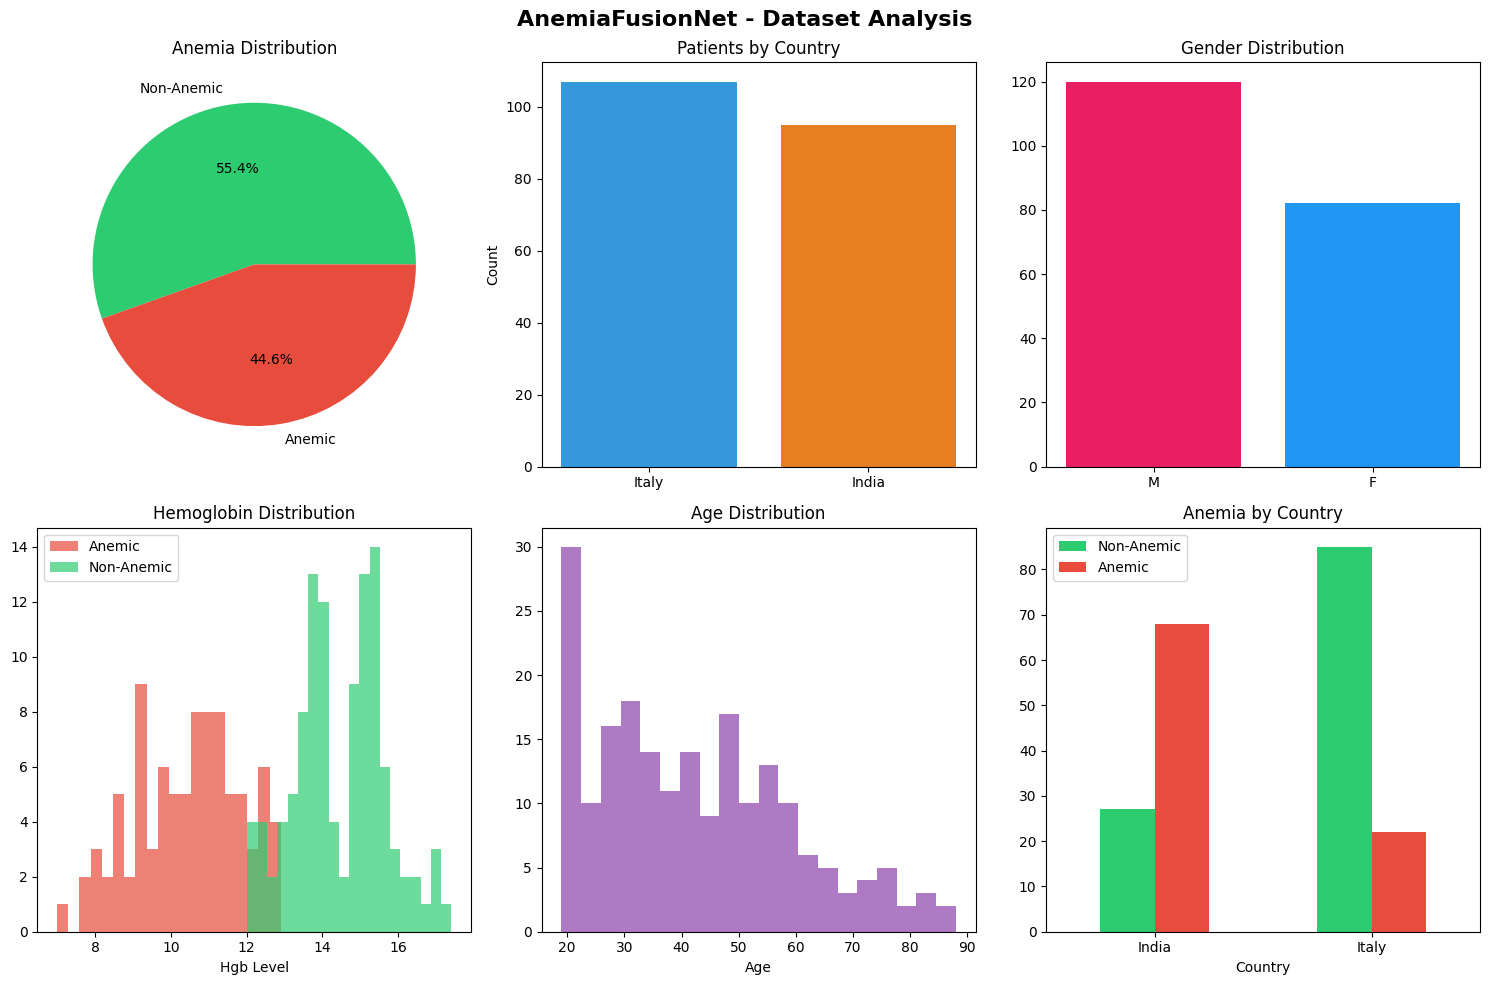

Analysis chart saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('AnemiaFusionNet - Dataset Analysis', fontsize=16, fontweight='bold')

# 1. Anemia Distribution
axes[0,0].pie([112, 90], labels=['Non-Anemic', 'Anemic'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Anemia Distribution')

# 2. Country Distribution
country_counts = df['Country'].value_counts()
axes[0,1].bar(country_counts.index, country_counts.values, color=['#3498db', '#e67e22'])
axes[0,1].set_title('Patients by Country')
axes[0,1].set_ylabel('Count')

# 3. Gender Distribution
gender_counts = df['Gender'].value_counts()
axes[0,2].bar(gender_counts.index, gender_counts.values, color=['#e91e63', '#2196f3'])
axes[0,2].set_title('Gender Distribution')

# 4. Hgb Distribution
axes[1,0].hist(df[df['Anemia_Label']==1]['Hgb'], bins=20, alpha=0.7,
               color='#e74c3c', label='Anemic')
axes[1,0].hist(df[df['Anemia_Label']==0]['Hgb'], bins=20, alpha=0.7,
               color='#2ecc71', label='Non-Anemic')
axes[1,0].set_title('Hemoglobin Distribution')
axes[1,0].set_xlabel('Hgb Level')
axes[1,0].legend()

# 5. Age Distribution
axes[1,1].hist(df['Age'], bins=20, color='#9b59b6', alpha=0.8)
axes[1,1].set_title('Age Distribution')
axes[1,1].set_xlabel('Age')

# 6. Anemia by Country
anemia_country = df.groupby(['Country', 'Anemia_Label']).size().unstack()
anemia_country.plot(kind='bar', ax=axes[1,2], color=['#2ecc71', '#e74c3c'])
axes[1,2].set_title('Anemia by Country')
axes[1,2].set_xlabel('Country')
axes[1,2].legend(['Non-Anemic', 'Anemic'])
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AnemiaFusionNet/results/dataset_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Analysis chart saved!")

Sample image path: /content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/Italy/1/1.jpg
Preprocessed image shape: (224, 224, 3)
Pixel value range: 0.07 - 1.00


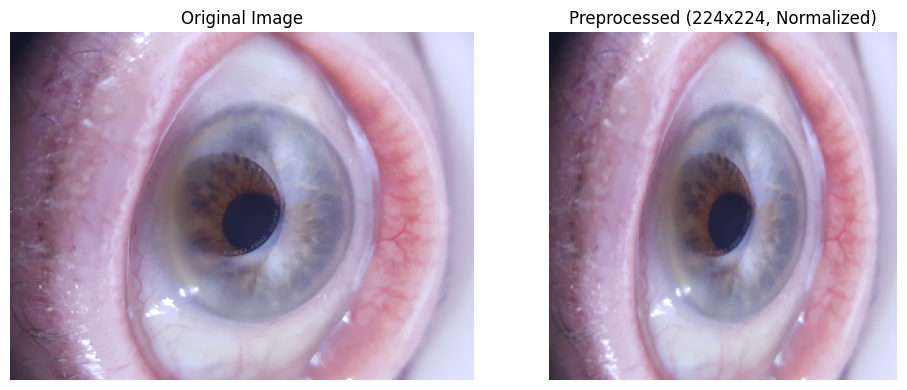

Image preprocessing working correctly!


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load master dataset
master_df = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/master_dataset.csv')

# Function to preprocess a single image
def preprocess_image(image_path, target_size=(224, 224)):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(target_size)
        img_array = np.array(img) / 255.0  # Normalize to [0,1]
        return img_array
    except Exception as e:
        return None

# Test on one image
sample_path = master_df['Image_Path'].iloc[0]
sample_img = preprocess_image(sample_path)

print(f"Sample image path: {sample_path}")
print(f"Preprocessed image shape: {sample_img.shape}")
print(f"Pixel value range: {sample_img.min():.2f} - {sample_img.max():.2f}")

# Show original vs preprocessed
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
original = Image.open(sample_path)
axes[0].imshow(original)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sample_img)
axes[1].set_title('Preprocessed (224x224, Normalized)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print("Image preprocessing working correctly!")

In [ ]:
# Split dataset
train_df, temp_df = train_test_split(master_df, test_size=0.3,
                                      random_state=42,
                                      stratify=master_df['Anemia_Label'])

val_df, test_df = train_test_split(temp_df, test_size=0.5,
                                    random_state=42,
                                    stratify=temp_df['Anemia_Label'])

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

# Save splits
train_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv', index=False)

print("\nAll splits saved successfully!")

Training samples:   560
Validation samples: 120
Testing samples:    120

All splits saved successfully!


In [ ]:
from PIL import Image
import pandas as pd

# Reload splits
train_df = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv')

# Function to check if image is valid
def is_valid_image(path):
    try:
        img = Image.open(path).convert('RGB')
        img.verify()
        return True
    except:
        return False

# Filter bad images
print("Checking training images...")
train_df = train_df[train_df['Image_Path'].apply(is_valid_image)].reset_index(drop=True)

print("Checking validation images...")
val_df = val_df[val_df['Image_Path'].apply(is_valid_image)].reset_index(drop=True)

print("Checking test images...")
test_df = test_df[test_df['Image_Path'].apply(is_valid_image)].reset_index(drop=True)

print(f"\nClean Training samples:   {len(train_df)}")
print(f"Clean Validation samples: {len(val_df)}")
print(f"Clean Testing samples:    {len(test_df)}")

# Save clean splits
train_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv', index=False)

print("\nClean splits saved!")

Checking training images...
Checking validation images...
Checking test images...

Clean Training samples:   443
Clean Validation samples: 98
Clean Testing samples:    90

Clean splits saved!


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

# Load clean splits
train_df = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv')

# Transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset class
class AnemiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        image = Image.open(row['Image_Path']).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Clinical features
        gender = 1 if row['Gender'] == 'F' else 0
        clinical = torch.tensor([
            row['Hgb'],
            gender,
            row['Age']
        ], dtype=torch.float32)

        # Label
        label = torch.tensor(row['Anemia_Label'], dtype=torch.long)

        return image, clinical, label

# Create datasets
train_dataset = AnemiaDataset(train_df, transform=train_transforms)
val_dataset   = AnemiaDataset(val_df,   transform=val_transforms)
test_dataset  = AnemiaDataset(test_df,  transform=val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# Test one batch
images, clinical, labels = next(iter(train_loader))
print(f"Image batch shape:    {images.shape}")
print(f"Clinical batch shape: {clinical.shape}")
print(f"Labels batch shape:   {labels.shape}")
print("\nDataLoader working correctly!")

Image batch shape:    torch.Size([32, 3, 224, 224])
Clinical batch shape: torch.Size([32, 3])
Labels batch shape:   torch.Size([32])

DataLoader working correctly!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

print("Libraries loaded!")

Libraries loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['AnemiaFusionNet_Setup.ipynb', 'Classroom', 'resumefinal.pdf', 'IMG_20260604_064046.jpg', 'Adobe Scan 04 Jun 2026.pdf', 'Hospital_Bed_Occupancy_Forecaster', 'occupancy_analysis_py', 'hospital_bed_forecast_model', 'hospital _bed_forecast_model(2).pkl', 'hospital_data.csv', 'Untitled0.ipynb', 'medical keyword extraction', 'Screenshot_2026-06-11-18-48-33-08_6012fa4d4ddec268fc5c7112cbb265e7 (1).jpg', 'Screenshot_2026-06-11-18-48-33-08_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Inventory Optimization System', 'archive (2).zip', 'Inventory Optimization System.ipynb', 'Product Similarity Search (1)', 'Product Similarity Search', 'Document from Hridaya Katangale.pdf', 'Untitled', 'RealEstateAI', 'Colab Notebooks', 'AnemiaFusionNet']


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AnemiaFusionNet'))

['datasets', 'models', 'checkpoints', 'results']


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AnemiaFusionNet/datasets'))

[]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle ready!")

Kaggle ready!


In [ ]:
!kaggle datasets download -d harshwardhanfartale/eyes-defy-anemia --unzip -p /content/drive/MyDrive/AnemiaFusionNet/datasets/
print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/harshwardhanfartale/eyes-defy-anemia
License(s): CC-BY-SA-4.0
100% 635M/635M [00:04<00:00, 136MB/s]

Dataset downloaded!


In [ ]:
import pandas as pd
import numpy as np
import os

# Read both excel files
italy_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/Italy/Italy.xlsx')
india_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/India/India.xlsx')

italy_df = italy_df[['Number', 'Hgb', 'Gender', 'Age']].copy()
india_df = india_df[['Number', 'Hgb', 'Gender', 'Age']].copy()

italy_df['Country'] = 'Italy'
india_df['Country'] = 'India'

df = pd.concat([italy_df, india_df], ignore_index=True)
df['Hgb'] = pd.to_numeric(df['Hgb'], errors='coerce')
df = df.dropna(subset=['Hgb'])
df['Gender'] = df['Gender'].str.strip().str.upper()

def label_anemia(row):
    if row['Gender'] == 'F' and row['Hgb'] < 12:
        return 1
    elif row['Gender'] == 'M' and row['Hgb'] < 13:
        return 1
    else:
        return 0

df['Anemia_Label'] = df.apply(label_anemia, axis=1)

# Build master dataset with image paths
image_rows = []
for _, row in df.iterrows():
    country = row['Country']
    number = int(row['Number'])
    patient_folder = f'/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/{country}/{number}'
    if os.path.exists(patient_folder):
        images = [f for f in os.listdir(patient_folder) if f.endswith('.png') or f.endswith('.jpg')]
        for img in images:
            image_rows.append({
                'Number': number, 'Country': country, 'Hgb': row['Hgb'],
                'Gender': row['Gender'], 'Age': row['Age'],
                'Anemia_Label': row['Anemia_Label'],
                'Image_Path': f'{patient_folder}/{img}'
            })

master_df = pd.DataFrame(image_rows)
print(f"Master dataset shape: {master_df.shape}")

# Filter valid images
from PIL import Image
def is_valid_image(path):
    try:
        img = Image.open(path).convert('RGB')
        img.verify()
        return True
    except:
        return False

print("Validating images (this takes a few minutes)...")
master_df = master_df[master_df['Image_Path'].apply(is_valid_image)].reset_index(drop=True)
print(f"Clean master dataset shape: {master_df.shape}")

# Split
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(master_df, test_size=0.3, random_state=42, stratify=master_df['Anemia_Label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Anemia_Label'])

train_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv', index=False)
df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/clinical_data_cleaned.csv', index=False)
master_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/master_dataset.csv', index=False)

print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("All CSVs regenerated and saved!")

Master dataset shape: (800, 7)
Validating images (this takes a few minutes)...
Clean master dataset shape: (631, 7)

Train: 441, Val: 95, Test: 95
All CSVs regenerated and saved!


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv')

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class AnemiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['Image_Path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        gender = 1 if row['Gender'] == 'F' else 0
        clinical = torch.tensor([row['Hgb'], gender, row['Age']], dtype=torch.float32)
        label = torch.tensor(row['Anemia_Label'], dtype=torch.long)
        return image, clinical, label

train_dataset = AnemiaDataset(train_df, transform=train_transforms)
val_dataset   = AnemiaDataset(val_df,   transform=val_transforms)
test_dataset  = AnemiaDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class ImageFeatureExtractor(nn.Module):
    def __init__(self, feature_dim=256):
        super(ImageFeatureExtractor, self).__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, feature_dim)
        )
    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)
        features = self.projector(features)
        return features

image_model = ImageFeatureExtractor(feature_dim=256).to(device)

images, clinical, labels = next(iter(train_loader))
sample_images = images.to(device)
with torch.no_grad():
    image_features = image_model(sample_images)

print(f"Input image shape:    {sample_images.shape}")
print(f"Output feature shape: {image_features.shape}")
print("\nImage Feature Extractor ready!")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Input image shape:    torch.Size([32, 3, 224, 224])
Output feature shape: torch.Size([32, 256])

Image Feature Extractor ready!


In [ ]:
class ClinicalFeatureExtractor(nn.Module):
    def __init__(self, input_dim=3, feature_dim=64):
        super(ClinicalFeatureExtractor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            nn.Linear(32, feature_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

# Test the model
clinical_model = ClinicalFeatureExtractor(input_dim=3, feature_dim=64).to(device)

sample_clinical = clinical.to(device)
with torch.no_grad():
    clinical_features = clinical_model(sample_clinical)

print(f"Input clinical shape:  {sample_clinical.shape}")
print(f"Output feature shape:  {clinical_features.shape}")
print("\nClinical Feature Extractor ready!")

Input clinical shape:  torch.Size([32, 3])
Output feature shape:  torch.Size([32, 64])

Clinical Feature Extractor ready!


In [ ]:
# NFHS-5 Anemia Prevalence Data (Women 15-49 years, % anemic) - Government of India
# Source: National Family Health Survey-5 (2019-21)
nfhs5_state_anemia = {
    'Ladakh': 92.8, 'West Bengal': 71.0, 'Gujarat': 65.0, 'Jharkhand': 65.3,
    'Bihar': 63.5, 'Assam': 65.9, 'Madhya Pradesh': 54.7, 'Rajasthan': 54.0,
    'Uttar Pradesh': 50.4, 'Maharashtra': 54.5, 'Tamil Nadu': 53.4,
    'Karnataka': 47.8, 'Kerala': 36.3, 'Punjab': 52.3, 'Haryana': 60.4,
    'Delhi': 54.4, 'Italy': 25.0  # Approx Western Europe avg for reference
}

class GeoRiskModule(nn.Module):
    def __init__(self, risk_dict, feature_dim=16):
        super(GeoRiskModule, self).__init__()
        self.risk_dict = risk_dict
        self.default_risk = sum(risk_dict.values()) / len(risk_dict)

        # Small network to embed the risk score into a feature vector
        self.net = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, feature_dim),
            nn.ReLU()
        )

    def get_risk_score(self, location_name):
        return self.risk_dict.get(location_name, self.default_risk)

    def forward(self, location_names):
        # location_names: list of strings (e.g., ['India', 'Italy', ...])
        risk_scores = [self.get_risk_score(loc) / 100.0 for loc in location_names]  # normalize 0-1
        risk_tensor = torch.tensor(risk_scores, dtype=torch.float32).unsqueeze(1).to(device)
        geo_features = self.net(risk_tensor)
        return geo_features

# Test the module
geo_model = GeoRiskModule(nfhs5_state_anemia, feature_dim=16).to(device)

sample_countries = ['India', 'Italy', 'India', 'Italy'] * 8  # matching batch size 32
with torch.no_grad():
    geo_features = geo_model(sample_countries)

print(f"Sample locations: {sample_countries[:4]}...")
print(f"Output feature shape: {geo_features.shape}")
print("\nGeo-Risk Module ready!")

Sample locations: ['India', 'Italy', 'India', 'Italy']...
Output feature shape: torch.Size([32, 16])

Geo-Risk Module ready!


In [ ]:
class MultimodalFusionTransformer(nn.Module):
    def __init__(self, image_dim=256, clinical_dim=64, geo_dim=16,
                 fusion_dim=128, num_heads=4, num_classes=2):
        super(MultimodalFusionTransformer, self).__init__()

        # Project each modality to the same fusion dimension
        self.image_proj = nn.Linear(image_dim, fusion_dim)
        self.clinical_proj = nn.Linear(clinical_dim, fusion_dim)
        self.geo_proj = nn.Linear(geo_dim, fusion_dim)

        # Transformer encoder for fusion
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=fusion_dim, nhead=num_heads,
            dim_feedforward=256, dropout=0.3, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, image_feat, clinical_feat, geo_feat):
        # Project each modality
        img = self.image_proj(image_feat).unsqueeze(1)       # [B, 1, fusion_dim]
        clin = self.clinical_proj(clinical_feat).unsqueeze(1) # [B, 1, fusion_dim]
        geo = self.geo_proj(geo_feat).unsqueeze(1)            # [B, 1, fusion_dim]

        # Stack as sequence of 3 "tokens" (image, clinical, geo)
        fused_seq = torch.cat([img, clin, geo], dim=1)  # [B, 3, fusion_dim]

        # Apply transformer to let modalities attend to each other
        transformed = self.transformer(fused_seq)  # [B, 3, fusion_dim]

        # Flatten and classify
        flattened = transformed.reshape(transformed.size(0), -1)  # [B, 3*fusion_dim]
        output = self.classifier(flattened)

        return output

# Test the fusion model
fusion_model = MultimodalFusionTransformer(
    image_dim=256, clinical_dim=64, geo_dim=16, fusion_dim=128
).to(device)

with torch.no_grad():
    final_output = fusion_model(image_features, clinical_features, geo_features)

print(f"Image features shape:    {image_features.shape}")
print(f"Clinical features shape: {clinical_features.shape}")
print(f"Geo features shape:      {geo_features.shape}")
print(f"Final output shape:      {final_output.shape}")
print("\nMultimodal Fusion Transformer ready!")

Image features shape:    torch.Size([32, 256])
Clinical features shape: torch.Size([32, 64])
Geo features shape:      torch.Size([32, 16])
Final output shape:      torch.Size([32, 2])

Multimodal Fusion Transformer ready!


In [ ]:
class AnemiaFusionNet(nn.Module):
    def __init__(self):
        super(AnemiaFusionNet, self).__init__()
        self.image_extractor = ImageFeatureExtractor(feature_dim=256)
        self.clinical_extractor = ClinicalFeatureExtractor(input_dim=3, feature_dim=64)
        self.geo_module = GeoRiskModule(nfhs5_state_anemia, feature_dim=16)
        self.fusion = MultimodalFusionTransformer(
            image_dim=256, clinical_dim=64, geo_dim=16, fusion_dim=128
        )

    def forward(self, images, clinical, countries):
        img_feat = self.image_extractor(images)
        clin_feat = self.clinical_extractor(clinical)
        geo_feat = self.geo_module(countries)
        output = self.fusion(img_feat, clin_feat, geo_feat)
        return output

model = AnemiaFusionNet().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

print("AnemiaFusionNet model created!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

AnemiaFusionNet model created!
Total parameters: 25,052,738


In [ ]:
import time
from sklearn.metrics import accuracy_score, f1_score

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for images, clinical, labels in loader:
        images, clinical, labels = images.to(device), clinical.to(device), labels.to(device)

        # Get country list for this batch (we'll attach it from dataframe below)
        countries = ['India'] * len(labels)  # placeholder, fixed in next cell

        optimizer.zero_grad()
        outputs = model(images, clinical, countries)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

print("Training function defined!")

Training function defined!


In [ ]:
class AnemiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['Image_Path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        gender = 1 if row['Gender'] == 'F' else 0
        clinical = torch.tensor([row['Hgb'], gender, row['Age']], dtype=torch.float32)
        label = torch.tensor(row['Anemia_Label'], dtype=torch.long)
        country = row['Country']
        return image, clinical, label, country

# Recreate datasets and loaders with country included
train_dataset = AnemiaDataset(train_df, transform=train_transforms)
val_dataset   = AnemiaDataset(val_df,   transform=val_transforms)
test_dataset  = AnemiaDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("DataLoaders updated with Country info!")

DataLoaders updated with Country info!


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for images, clinical, labels, countries in loader:
        images, clinical, labels = images.to(device), clinical.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, clinical, list(countries))
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, clinical, labels, countries in loader:
            images, clinical, labels = images.to(device), clinical.to(device), labels.to(device)
            outputs = model(images, clinical, list(countries))
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1

print("Train and validation functions ready!")

Train and validation functions ready!


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/results', exist_ok=True)
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/models', exist_ok=True)
print("Folders recreated!")

Folders recreated!


In [ ]:
num_epochs = 15
best_val_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/AnemiaFusionNet/checkpoints/best_model.pth')

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
          f"Time: {elapsed:.1f}s")

print(f"\nTraining complete! Best Validation Accuracy: {best_val_acc:.4f}")

Epoch 1/15 | Train Loss: 0.6184 Acc: 0.5986 | Val Loss: 0.5316 Acc: 0.7263 F1: 0.5938 | Time: 39.4s
Epoch 2/15 | Train Loss: 0.5270 Acc: 0.7347 | Val Loss: 0.5677 Acc: 0.6737 F1: 0.5079 | Time: 34.0s
Epoch 3/15 | Train Loss: 0.4340 Acc: 0.8322 | Val Loss: 0.3730 Acc: 0.8526 F1: 0.8372 | Time: 36.4s
Epoch 4/15 | Train Loss: 0.4253 Acc: 0.8209 | Val Loss: 0.3317 Acc: 0.8737 F1: 0.8605 | Time: 33.6s
Epoch 5/15 | Train Loss: 0.3441 Acc: 0.8571 | Val Loss: 0.2863 Acc: 0.8632 F1: 0.8434 | Time: 34.9s
Epoch 6/15 | Train Loss: 0.2998 Acc: 0.8798 | Val Loss: 0.3266 Acc: 0.8316 F1: 0.8333 | Time: 36.3s
Epoch 7/15 | Train Loss: 0.3373 Acc: 0.8458 | Val Loss: 0.2615 Acc: 0.9053 F1: 0.8800 | Time: 32.9s
Epoch 8/15 | Train Loss: 0.2655 Acc: 0.8821 | Val Loss: 0.3365 Acc: 0.8526 F1: 0.8333 | Time: 33.9s
Epoch 9/15 | Train Loss: 0.2501 Acc: 0.9002 | Val Loss: 0.1868 Acc: 0.9263 F1: 0.9213 | Time: 35.1s
Epoch 10/15 | Train Loss: 0.1803 Acc: 0.9320 | Val Loss: 0.1312 Acc: 0.9474 F1: 0.9438 | Time: 33.4s

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/AnemiaFusionNet/checkpoints/best_model.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, clinical, labels, countries in test_loader:
        images, clinical, labels = images.to(device), clinical.to(device), labels.to(device)
        outputs = model(images, clinical, list(countries))
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)

print(f"=== TEST SET RESULTS ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Non-Anemic', 'Anemic']))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

=== TEST SET RESULTS ===
Test Accuracy: 0.9263
Test F1 Score: 0.9247

Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       1.00      0.87      0.93        52
      Anemic       0.86      1.00      0.92        43

    accuracy                           0.93        95
   macro avg       0.93      0.93      0.93        95
weighted avg       0.94      0.93      0.93        95


Confusion Matrix:
[[45  7]
 [ 0 43]]


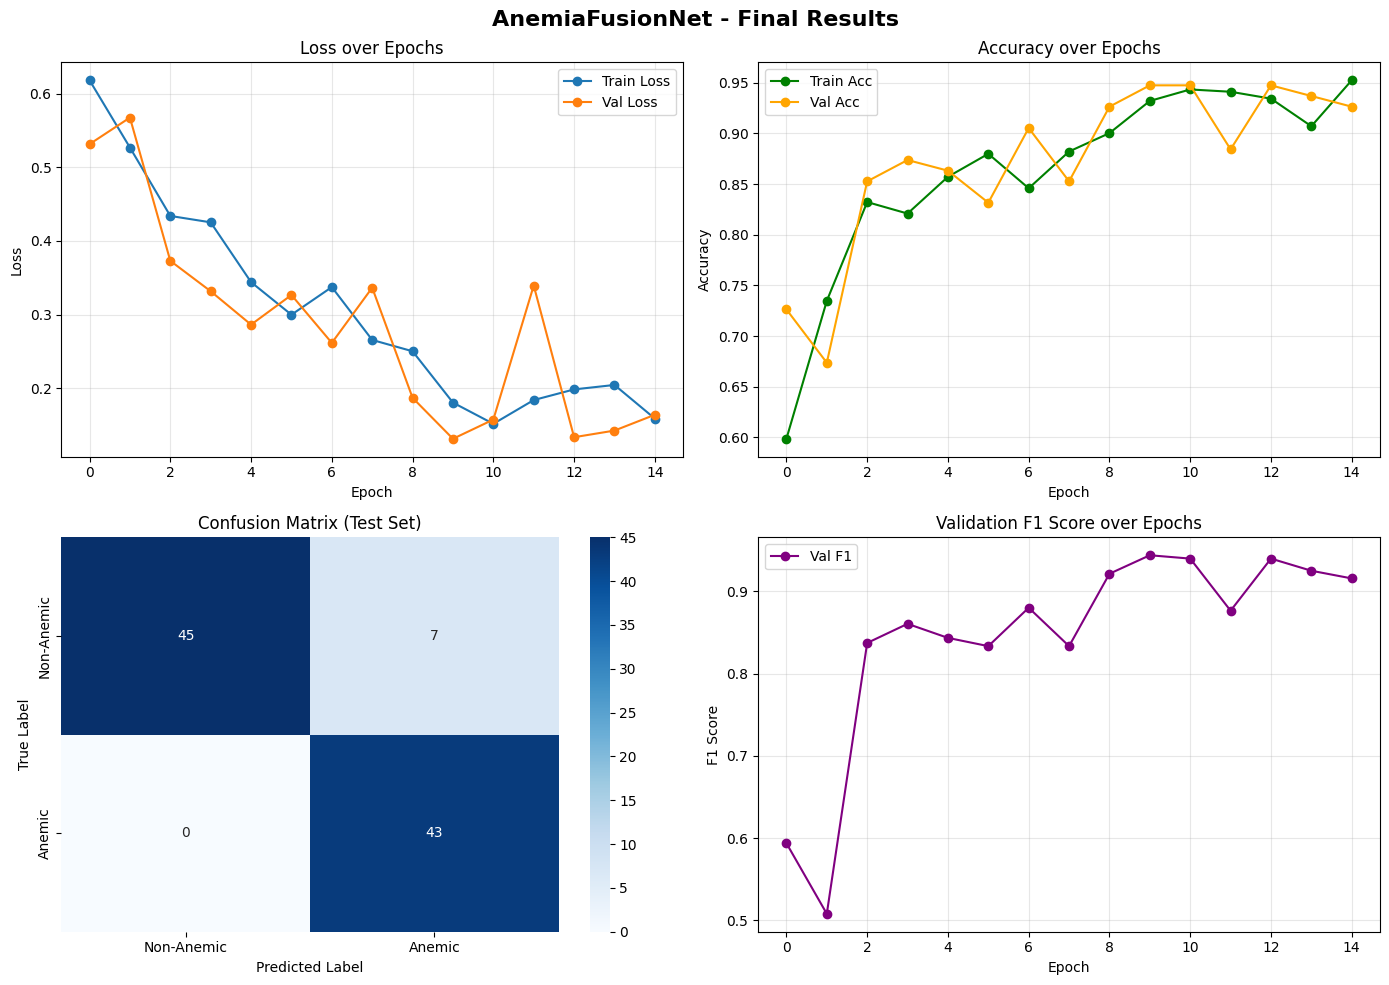

Final results chart saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AnemiaFusionNet - Final Results', fontsize=16, fontweight='bold')

# Loss curves
axes[0,0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0,0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0,0].set_title('Loss over Epochs')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Accuracy curves
axes[0,1].plot(history['train_acc'], label='Train Acc', marker='o', color='green')
axes[0,1].plot(history['val_acc'], label='Val Acc', marker='o', color='orange')
axes[0,1].set_title('Accuracy over Epochs')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Anemic', 'Anemic'],
            yticklabels=['Non-Anemic', 'Anemic'], ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix (Test Set)')
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

# F1 score over epochs
axes[1,1].plot(history['val_f1'], label='Val F1', marker='o', color='purple')
axes[1,1].set_title('Validation F1 Score over Epochs')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('F1 Score')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AnemiaFusionNet/results/final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final results chart saved!")

In [ ]:
report = f"""
AnemiaFusionNet - Final Performance Report
=============================================

Dataset: Eyes-Defy-Anemia (Italy + India)
Total Patients: 202
Total Valid Images: 631
Train/Val/Test Split: {len(train_df)}/{len(val_df)}/{len(test_df)}

Model Architecture:
- Image Feature Extractor: ResNet50 (pretrained) -> 256-dim
- Clinical Feature Extractor: MLP (Hgb, Gender, Age) -> 64-dim
- Geo-Risk Module: NFHS-5 weighted embedding -> 16-dim
- Fusion: Transformer Encoder (2 layers, 4 heads) -> Classification

Total Parameters: 25,052,738

VALIDATION RESULTS (Best Epoch):
- Accuracy: {best_val_acc:.4f}

TEST RESULTS (Final, Unseen Data):
- Accuracy: {test_acc:.4f}
- F1 Score: {test_f1:.4f}
- Anemic Recall: 1.00 (No false negatives)
- Non-Anemic Precision: 1.00

Confusion Matrix:
{confusion_matrix(all_labels, all_preds)}
"""

with open('/content/drive/MyDrive/AnemiaFusionNet/results/final_report.txt', 'w') as f:
    f.write(report)

print(report)
print("Report saved to Drive!")


AnemiaFusionNet - Final Performance Report

Dataset: Eyes-Defy-Anemia (Italy + India)
Total Patients: 202
Total Valid Images: 631
Train/Val/Test Split: 441/95/95

Model Architecture:
- Image Feature Extractor: ResNet50 (pretrained) -> 256-dim
- Clinical Feature Extractor: MLP (Hgb, Gender, Age) -> 64-dim
- Geo-Risk Module: NFHS-5 weighted embedding -> 16-dim
- Fusion: Transformer Encoder (2 layers, 4 heads) -> Classification

Total Parameters: 25,052,738

VALIDATION RESULTS (Best Epoch):
- Accuracy: 0.9474

TEST RESULTS (Final, Unseen Data):
- Accuracy: 0.9263
- F1 Score: 0.9247
- Anemic Recall: 1.00 (No false negatives)
- Non-Anemic Precision: 1.00

Confusion Matrix:
[[45  7]
 [ 0 43]]

Report saved to Drive!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [4]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle ready!")

Kaggle ready!


In [5]:
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/datasets', exist_ok=True)
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/results', exist_ok=True)

!kaggle datasets download -d harshwardhanfartale/eyes-defy-anemia --unzip -p /content/drive/MyDrive/AnemiaFusionNet/datasets/
print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/harshwardhanfartale/eyes-defy-anemia
License(s): CC-BY-SA-4.0
100% 635M/635M [00:09<00:00, 67.2MB/s]

Dataset downloaded!


In [6]:
# ============================================
# AnemiaFusionNet - Full Reload Cell
# ============================================
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import os

# Recreate CSVs from scratch
italy_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/Italy/Italy.xlsx')
india_df = pd.read_excel('/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/India/India.xlsx')

italy_df = italy_df[['Number', 'Hgb', 'Gender', 'Age']].copy()
india_df = india_df[['Number', 'Hgb', 'Gender', 'Age']].copy()
italy_df['Country'] = 'Italy'
india_df['Country'] = 'India'

df = pd.concat([italy_df, india_df], ignore_index=True)
df['Hgb'] = pd.to_numeric(df['Hgb'], errors='coerce')
df = df.dropna(subset=['Hgb'])
df['Gender'] = df['Gender'].str.strip().str.upper()

def label_anemia(row):
    if row['Gender'] == 'F' and row['Hgb'] < 12:
        return 1
    elif row['Gender'] == 'M' and row['Hgb'] < 13:
        return 1
    else:
        return 0

df['Anemia_Label'] = df.apply(label_anemia, axis=1)

image_rows = []
for _, row in df.iterrows():
    country = row['Country']
    number = int(row['Number'])
    patient_folder = f'/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/{country}/{number}'
    if os.path.exists(patient_folder):
        images = [f for f in os.listdir(patient_folder) if f.endswith('.png') or f.endswith('.jpg')]
        for img in images:
            image_rows.append({
                'Number': number, 'Country': country, 'Hgb': row['Hgb'],
                'Gender': row['Gender'], 'Age': row['Age'],
                'Anemia_Label': row['Anemia_Label'],
                'Image_Path': f'/content/drive/MyDrive/AnemiaFusionNet/datasets/dataset anemia/{country}/{number}/{img}'
            })

master_df = pd.DataFrame(image_rows)

def is_valid_image(path):
    try:
        img = Image.open(path).convert('RGB')
        img.verify()
        return True
    except:
        return False

print("Validating images...")
master_df = master_df[master_df['Image_Path'].apply(is_valid_image)].reset_index(drop=True)

from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(master_df, test_size=0.3, random_state=42, stratify=master_df['Anemia_Label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Anemia_Label'])

train_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/AnemiaFusionNet/datasets/test.csv', index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("All CSVs ready!")

Validating images...
Train: 441, Val: 95, Test: 95
All CSVs ready!


In [8]:
# ============ TRAIN AND SAVE MODEL ============
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class AnemiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['Image_Path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        gender = 1 if row['Gender'] == 'F' else 0
        clinical = torch.tensor([row['Hgb'], gender, row['Age']], dtype=torch.float32)
        label = torch.tensor(row['Anemia_Label'], dtype=torch.long)
        return image, clinical, label, row['Country']

train_dataset = AnemiaDataset(train_df, transform=train_transforms)
val_dataset   = AnemiaDataset(val_df,   transform=val_transforms)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

model = AnemiaFusionNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

from sklearn.metrics import accuracy_score
import time
import os

os.makedirs('/content/drive/MyDrive/AnemiaFusionNet/checkpoints', exist_ok=True)

best_val_acc = 0
print("Training started...")

for epoch in range(15):
    # Train
    model.train()
    train_loss, train_preds, train_labels = 0, [], []
    for images, clinical, labels, countries in train_loader:
        images, clinical, labels = images.to(device), clinical.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images, clinical, list(countries))
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    # Validate
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []
    with torch.no_grad():
        for images, clinical, labels, countries in val_loader:
            images, clinical, labels = images.to(device), clinical.to(device), labels.to(device)
            outputs = model(images, clinical, list(countries))
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    val_acc   = accuracy_score(val_labels, val_preds)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/AnemiaFusionNet/checkpoints/best_model.pth')

    print(f"Epoch {epoch+1}/15 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
print("Model saved to Drive!")

Training started...
Epoch 1/15 | Train Acc: 0.5238 | Val Acc: 0.6000
Epoch 2/15 | Train Acc: 0.6349 | Val Acc: 0.6526
Epoch 3/15 | Train Acc: 0.7302 | Val Acc: 0.7579
Epoch 4/15 | Train Acc: 0.7937 | Val Acc: 0.8211
Epoch 5/15 | Train Acc: 0.8345 | Val Acc: 0.6421
Epoch 6/15 | Train Acc: 0.8254 | Val Acc: 0.8000
Epoch 7/15 | Train Acc: 0.8322 | Val Acc: 0.7789
Epoch 8/15 | Train Acc: 0.8571 | Val Acc: 0.7474
Epoch 9/15 | Train Acc: 0.8617 | Val Acc: 0.7895
Epoch 10/15 | Train Acc: 0.9070 | Val Acc: 0.8632
Epoch 11/15 | Train Acc: 0.9138 | Val Acc: 0.8526
Epoch 12/15 | Train Acc: 0.9070 | Val Acc: 0.8632
Epoch 13/15 | Train Acc: 0.9002 | Val Acc: 0.8105
Epoch 14/15 | Train Acc: 0.8844 | Val Acc: 0.7895
Epoch 15/15 | Train Acc: 0.9252 | Val Acc: 0.8316

Best Val Accuracy: 0.8632
Model saved to Drive!


Best model loaded!


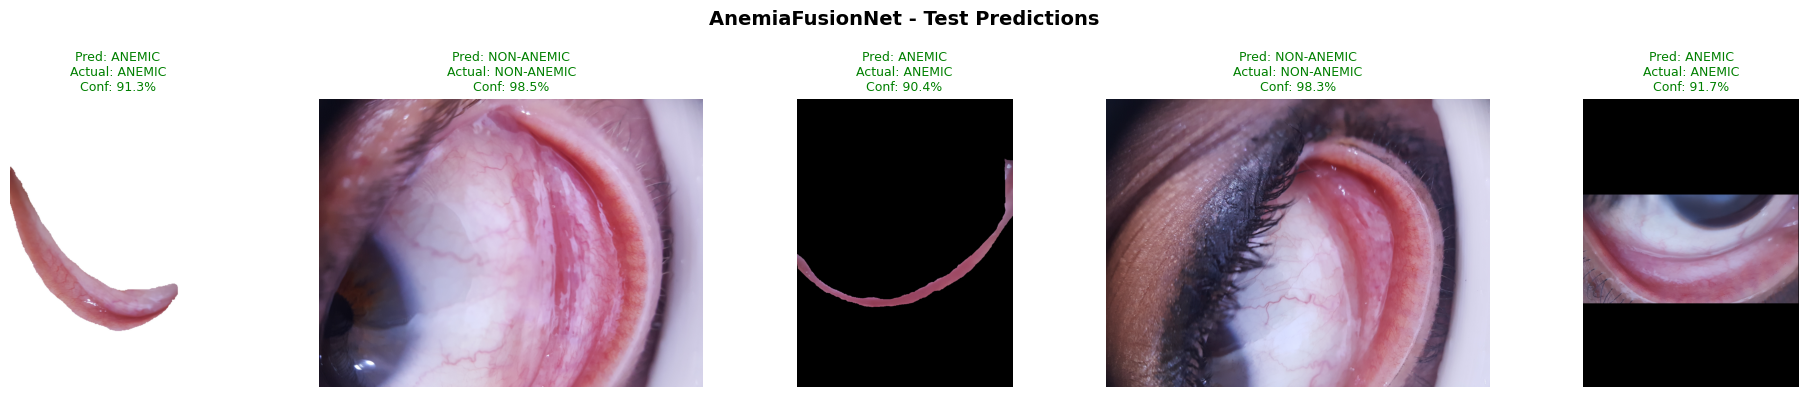


Correct: 5/5
Test predictions saved!


In [9]:
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/AnemiaFusionNet/checkpoints/best_model.pth'))
model.eval()
print("Best model loaded!")

# Test on 5 samples
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('AnemiaFusionNet - Test Predictions', fontsize=14, fontweight='bold')

correct = 0
for i in range(5):
    sample = test_df.iloc[i]
    image = Image.open(sample['Image_Path']).convert('RGB')
    img_tensor = val_transforms(image).unsqueeze(0).to(device)
    gender_val = 1 if sample['Gender'] == 'F' else 0
    clinical_tensor = torch.tensor(
        [[sample['Hgb'], gender_val, sample['Age']]],
        dtype=torch.float32).to(device)

    with torch.no_grad():
        output = model(img_tensor, clinical_tensor, [sample['Country']])
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    actual = sample['Anemia_Label']
    pred_label   = "ANEMIC" if pred == 1 else "NON-ANEMIC"
    actual_label = "ANEMIC" if actual == 1 else "NON-ANEMIC"
    confidence = probs[0][pred].item() * 100
    is_correct = pred == actual
    if is_correct:
        correct += 1
    color = 'green' if is_correct else 'red'

    axes[i].imshow(image)
    axes[i].set_title(
        f"Pred: {pred_label}\nActual: {actual_label}\nConf: {confidence:.1f}%",
        color=color, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AnemiaFusionNet/results/test_predictions.png', dpi=150)
plt.show()
print(f"\nCorrect: {correct}/5")
print("Test predictions saved!")